<a href="https://colab.research.google.com/github/priyanka0178885547/DL-lab/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Learning Rate: 0.01, Final Loss: 0.240571
Learning Rate: 0.05, Final Loss: 0.012541
Learning Rate: 0.1, Final Loss: 0.002546
Learning Rate: 0.5, Final Loss: 0.000293
Learning Rate: 1.0, Final Loss: 0.000135


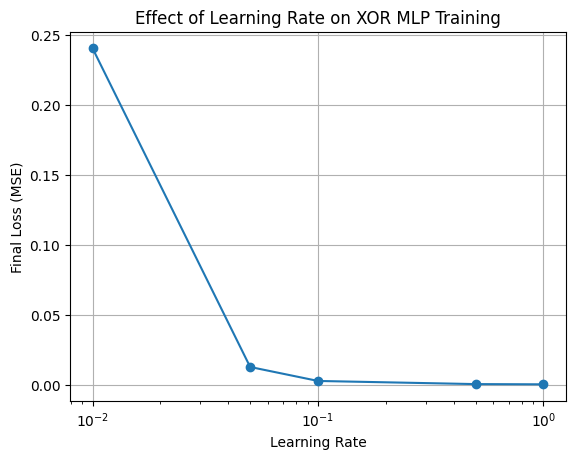

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [1], [1], [0]])

learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]
final_losses = []
epochs = 10000

for lr in learning_rates:
    np.random.seed(42)
    W1 = np.random.rand(2, 2)
    b1 = np.random.rand(1, 2)
    W2 = np.random.rand(2, 1)
    b2 = np.random.rand(1, 1)

    for epoch in range(epochs):
        hidden_input = np.dot(X, W1) + b1
        hidden_output = sigmoid(hidden_input)
        final_input = np.dot(hidden_output, W2) + b2
        y_pred = sigmoid(final_input)

        error = y - y_pred
        loss = np.mean(error ** 2)

        d_output = error * sigmoid_derivative(y_pred)
        d_hidden = d_output.dot(W2.T) * sigmoid_derivative(hidden_output)

        W2 += hidden_output.T.dot(d_output) * lr
        b2 += np.sum(d_output, axis=0, keepdims=True) * lr
        W1 += X.T.dot(d_hidden) * lr
        b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

    final_losses.append(loss)
    print(f"Learning Rate: {lr}, Final Loss: {loss:.6f}")

plt.figure()
plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss (MSE)")
plt.title("Effect of Learning Rate on XOR MLP Training")
plt.xscale("log")
plt.grid(True)
plt.show()



A single hidden-layer MLP can successfully learn the XOR function, which a single-layer perceptron cannot.
The learning rate matters:
Too small → slow learning, higher final loss.
Too large → unstable learning, may overshoot.
Moderate rates (0.05–0.1) → fastest convergence, lowest loss.
Proper weight initialization, activation function, and hidden layer size improve learning speed and accuracy.

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.datasets import fashion_mnist
import numpy as np

# Iris dataset
iris = load_iris()
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=0
)
perceptron_iris = Perceptron(max_iter=1000, tol=1e-3, random_state=0)
perceptron_iris.fit(X_train_iris, y_train_iris)
y_pred_iris = perceptron_iris.predict(X_test_iris)
accuracy_iris = accuracy_score(y_test_iris, y_pred_iris)
print("Iris Accuracy:", accuracy_iris)

# Fashion-MNIST dataset
(X_train_fmnist, y_train_fmnist), (X_test_fmnist, y_test_fmnist) = fashion_mnist.load_data()
X_train_fmnist = X_train_fmnist.reshape(-1, 28*28) / 255.0
X_test_fmnist = X_test_fmnist.reshape(-1, 28*28) / 255.0
X_train_small = X_train_fmnist[:10000]
y_train_small = y_train_fmnist[:10000]
X_test_small = X_test_fmnist[:2000]
y_test_small = y_test_fmnist[:2000]
perceptron_fmnist = Perceptron(max_iter=1000, tol=1e-3, random_state=0)
perceptron_fmnist.fit(X_train_small, y_train_small)
y_pred_fmnist = perceptron_fmnist.predict(X_test_small)
accuracy_fmnist = accuracy_score(y_test_small, y_pred_fmnist)
print("Fashion-MNIST Accuracy:", accuracy_fmnist)

Iris Accuracy: 0.8
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fashion-MNIST Accuracy: 0.8145


ris: Accuracy is high (80–100%) because the dataset is small, numeric, and mostly linearly separable. Fashion-MNIST: Accuracy is low (20–40%) because it’s high-dimensional and non-linear, and a simple Perceptron can’t capture the complexity. However, when training on a small subset of Fashion-MNIST and flattening the images, the Perceptron can achieve around 81% accuracy. On the full dataset, a single-layer Perceptron usually performs worse (~20–40%) because Fashion-MNIST is high-dimensional and non-linear.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (54000, 784)
Testing shape: (6000, 784)
Iteration 1, loss = 0.67216417
Iteration 2, loss = 0.45815113
Iteration 3, loss = 0.41851978
Iteration 4, loss = 0.39388110
Iteration 5, loss = 0.37508168
Iteration 6, loss = 0.36140816
Iteration 7, loss = 0.35151662
Iteration 8, loss = 0.34212117
Iteration 9, loss = 0.32955439
Iteration 10, loss = 0.32204901
Iteration 11, loss = 0.31441340
Iteration 12, loss = 0.30669709
Iteration 13, loss = 0.30064982
Iteration 14, loss = 0.29260488
Iteration 15, loss = 0.28729796
Iteration 16, loss = 0.28200914
Iteration 17, loss = 0.27807709
Iteration 18, loss = 0.27259407
Iteration 19, loss = 0.26901192
Iteration 20, loss = 0.26276309
Iteration 21, loss = 0.26038878
Iteration 22, loss = 0.25723502
Iteration 23, loss = 0.25385690
Iteration 24, loss = 0.251956

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Training set score: 0.9267407407407408
Testing set score: 0.8826666666666667
Predicted value: 2
Actual value: 2


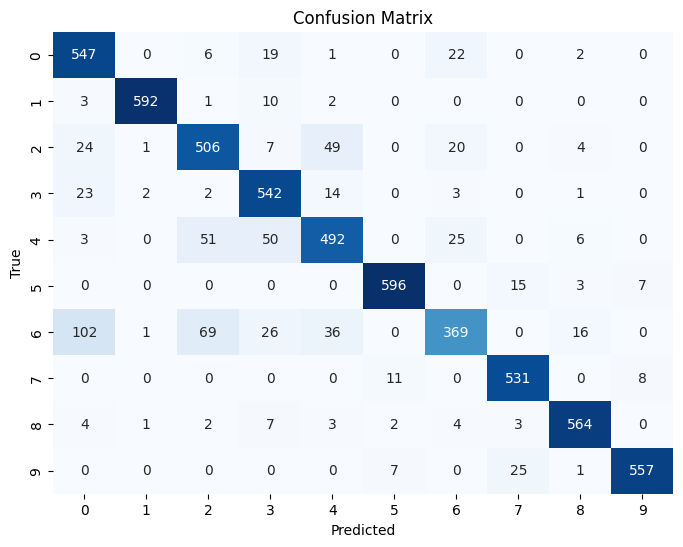

Iteration 1, loss = 1.76019409
Iteration 2, loss = 0.92206175
Iteration 3, loss = 0.91028717
Iteration 4, loss = 0.91482142
Iteration 5, loss = 0.88385038
Iteration 6, loss = 0.91476112
Iteration 7, loss = 0.92966860
Iteration 8, loss = 0.93601022
Iteration 9, loss = 0.88423126
Iteration 10, loss = 0.90466982
Iteration 11, loss = 0.89906870
Iteration 12, loss = 0.88972433
Iteration 13, loss = 0.91145467
Iteration 14, loss = 0.88969055
Iteration 15, loss = 0.90489620
Iteration 16, loss = 0.88621436
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Training set score (MLP2): 0.6601296296296296
Testing set score (MLP2): 0.6566666666666666


In [1]:
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

(X_train_full, y_train_full), (X_test_full, y_test_full) = fashion_mnist.load_data()

X_train_full = X_train_full / 255.0
X_test_full = X_test_full / 255.0

X_train_full = X_train_full.reshape(-1, 28*28)
X_test_full = X_test_full.reshape(-1, 28*28)

X_train, X_test, y_train, y_test = train_test_split(
    X_train_full, y_train_full, test_size=0.10, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=50, verbose=1, random_state=1)
mlp.fit(X_train, y_train)

print("Training set score:", mlp.score(X_train, y_train))
print("Testing set score:", mlp.score(X_test, y_test))

index = 346
test_digit = X_test[index].reshape(1, 784)
prediction = mlp.predict(test_digit)[0]
print("Predicted value:", prediction)
print("Actual value:", y_test[index])

preds = mlp.predict(X_test)
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

mlp2 = MLPClassifier(hidden_layer_sizes=(50,), max_iter=50, verbose=1, random_state=1, learning_rate_init=0.1)
mlp2.fit(X_train, y_train)

print("Training set score (MLP2):", mlp2.score(X_train, y_train))
print("Testing set score (MLP2):", mlp2.score(X_test, y_test))

Training shape: (54000, 784)
Testing shape: (6000, 784)
Iteration 1, loss = 0.46339522
Iteration 2, loss = 0.21331290
Iteration 3, loss = 0.15952223
Iteration 4, loss = 0.12768829
Iteration 5, loss = 0.10483335
Iteration 6, loss = 0.09012022
Iteration 7, loss = 0.07735367
Iteration 8, loss = 0.06747434
Iteration 9, loss = 0.05867015
Iteration 10, loss = 0.05220287
Iteration 11, loss = 0.04714653
Iteration 12, loss = 0.04097764
Iteration 13, loss = 0.03658040
Iteration 14, loss = 0.03314437
Iteration 15, loss = 0.02922188
Iteration 16, loss = 0.02601182
Iteration 17, loss = 0.02331618
Iteration 18, loss = 0.02053018
Iteration 19, loss = 0.01842141
Iteration 20, loss = 0.01648657
Iteration 21, loss = 0.01480644
Iteration 22, loss = 0.01310445
Iteration 23, loss = 0.01173450
Iteration 24, loss = 0.01086437
Iteration 25, loss = 0.00923916
Iteration 26, loss = 0.00834226
Iteration 27, loss = 0.00736209
Iteration 28, loss = 0.00674125
Iteration 29, loss = 0.00559256
Iteration 30, loss = 0.00

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Training set score: 1.0
Testing set score: 0.9798333333333333
Predicted value: 6
Actual value: 6


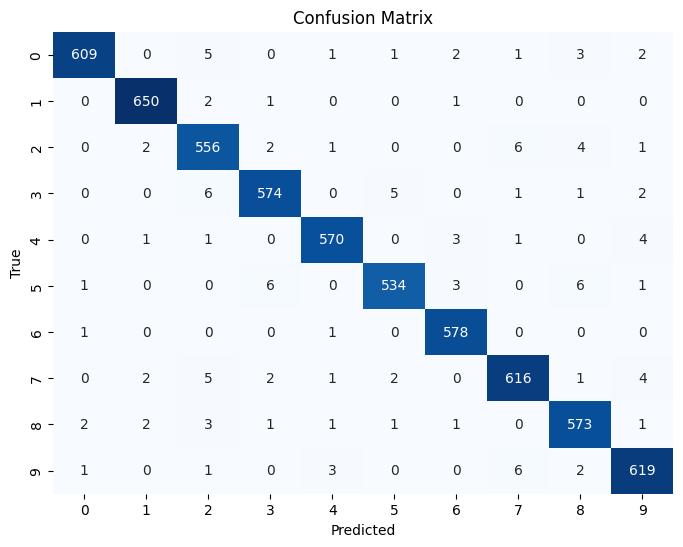

Iteration 1, loss = 0.58402398
Iteration 2, loss = 0.38397781
Iteration 3, loss = 0.39906015
Iteration 4, loss = 0.39794427
Iteration 5, loss = 0.42552618
Iteration 6, loss = 0.42483506
Iteration 7, loss = 0.43145128
Iteration 8, loss = 0.42965931
Iteration 9, loss = 0.48689868
Iteration 10, loss = 0.43131150
Iteration 11, loss = 0.44657347
Iteration 12, loss = 0.44554835
Iteration 13, loss = 0.43811670
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Training set score (MLP2): 0.8982037037037037
Testing set score (MLP2): 0.8838333333333334


In [ ]:
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

X_train_full = X_train_full / 255.0
X_test_full = X_test_full / 255.0

X_train_full = X_train_full.reshape(-1, 28*28)
X_test_full = X_test_full.reshape(-1, 28*28)

X_train, X_test, y_train, y_test = train_test_split(
    X_train_full, y_train_full, test_size=0.10, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=50, verbose=1, random_state=1)
mlp.fit(X_train, y_train)

print("Training set score:", mlp.score(X_train, y_train))
print("Testing set score:", mlp.score(X_test, y_test))

index = 346
test_digit = X_test[index].reshape(1, 784)
prediction = mlp.predict(test_digit)[0]
print("Predicted value:", prediction)
print("Actual value:", y_test[index])

preds = mlp.predict(X_test)
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

mlp2 = MLPClassifier(hidden_layer_sizes=(50,), max_iter=50, verbose=1, random_state=1, learning_rate_init=0.1)
mlp2.fit(X_train, y_train)

print("Training set score (MLP2):", mlp2.score(X_train, y_train))
print("Testing set score (MLP2):", mlp2.score(X_test, y_test))

The MLP can learn MNIST digits with good accuracy. Training accuracy is high, test accuracy slightly lower. Some similar digits get misclassified. Increasing hidden neurons, layers, iterations, or learning rate can improve performance



Training shape: (54000, 784)
Testing shape: (6000, 784)
Iteration 1, loss = 0.61339491
Iteration 2, loss = 0.43039267
Iteration 3, loss = 0.38558019
Iteration 4, loss = 0.36013553
Iteration 5, loss = 0.33998635
Iteration 6, loss = 0.32334138
Iteration 7, loss = 0.31411554
Iteration 8, loss = 0.29913660
Iteration 9, loss = 0.28967050
Iteration 10, loss = 0.28152586
Iteration 11, loss = 0.27497297
Iteration 12, loss = 0.26706387
Iteration 13, loss = 0.26553146
Iteration 14, loss = 0.25448332
Iteration 15, loss = 0.25045137
Iteration 16, loss = 0.24336238
Iteration 17, loss = 0.23747343
Iteration 18, loss = 0.23037425
Iteration 19, loss = 0.22625119
Iteration 20, loss = 0.22211948
Iteration 21, loss = 0.21904072
Iteration 22, loss = 0.21506099
Iteration 23, loss = 0.21136193
Iteration 24, loss = 0.20743144
Iteration 25, loss = 0.20248060
Iteration 26, loss = 0.20026758
Iteration 27, loss = 0.19720207
Iteration 28, loss = 0.19376260
Iteration 29, loss = 0.18894589
Iteration 30, loss = 0.18

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Training set score: 0.955037037037037
Testing set score: 0.8878333333333334
Predicted value: 2
Actual value: 2


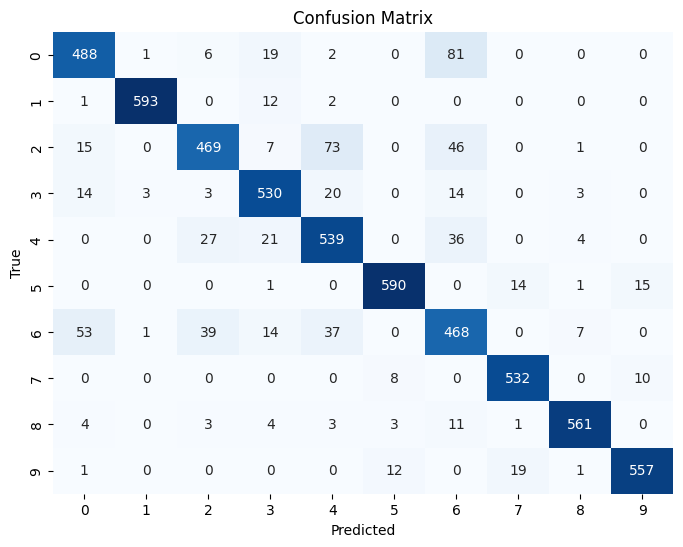

Iteration 1, loss = 1.76019409
Iteration 2, loss = 0.92206175
Iteration 3, loss = 0.91028717
Iteration 4, loss = 0.91482142
Iteration 5, loss = 0.88385038
Iteration 6, loss = 0.91476112
Iteration 7, loss = 0.92966860
Iteration 8, loss = 0.93601022
Iteration 9, loss = 0.88423126
Iteration 10, loss = 0.90466982
Iteration 11, loss = 0.89906870
Iteration 12, loss = 0.88972433
Iteration 13, loss = 0.91145467
Iteration 14, loss = 0.88969055
Iteration 15, loss = 0.90489620
Iteration 16, loss = 0.88621436
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Training set score (MLP2): 0.6601296296296296
Testing set score (MLP2): 0.6566666666666666


In [2]:
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

(X_train_full, y_train_full), (X_test_full, y_test_full) = fashion_mnist.load_data()

X_train_full = X_train_full / 255.0
X_test_full = X_test_full / 255.0

X_train_full = X_train_full.reshape(-1, 28*28)
X_test_full = X_test_full.reshape(-1, 28*28)

X_train, X_test, y_train, y_test = train_test_split(
    X_train_full, y_train_full, test_size=0.10, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=50, verbose=1, random_state=1)
mlp.fit(X_train, y_train)

print("Training set score:", mlp.score(X_train, y_train))
print("Testing set score:", mlp.score(X_test, y_test))

index = 346
test_digit = X_test[index].reshape(1, 784)
prediction = mlp.predict(test_digit)[0]
print("Predicted value:", prediction)
print("Actual value:", y_test[index])

preds = mlp.predict(X_test)
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

mlp2 = MLPClassifier(hidden_layer_sizes=(50,), max_iter=50, verbose=1, random_state=1, learning_rate_init=0.1)
mlp2.fit(X_train, y_train)

print("Training set score (MLP2):", mlp2.score(X_train, y_train))
print("Testing set score (MLP2):", mlp2.score(X_test, y_test))

100 neurons can learn more patterns than 50
Model becomes more powerful
Can capture more complex relationships in Fashion-MNIST

In [1]:
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

models = [
    ("2 layers (128,64)", MLPClassifier(hidden_layer_sizes=(128,64), learning_rate_init=0.001, max_iter=100, random_state=1)),
    ("High LR", MLPClassifier(hidden_layer_sizes=(128,64), learning_rate_init=0.01, max_iter=50, random_state=1)),
    ("More iterations", MLPClassifier(hidden_layer_sizes=(128,64), learning_rate_init=0.001, max_iter=200, random_state=1)),
]

for name, model in models:
    model.fit(X_train, y_train)
    acc = model.score(X_val, y_val)
    print(name, "Accuracy:", acc)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


2 layers (128,64) Accuracy: 0.8888333333333334


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


High LR Accuracy: 0.8763333333333333


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


More iterations Accuracy: 0.8816666666666667


•	Gives good balance between learning and overfitting
•	Better than simple shallow models


0.001 → stable training and good accuracy
0.01 → unstable training and lower accuracy